# [LAB-09] 선형회귀ㅣ4-다중선형회귀(실습코드).ipynb

## #01. 준비작업 

### 1. 라이브러리 참조 

In [41]:
from jussam import load_data
from helpers import *

import numpy as np
from pandas import DataFrame
from IPython.display import display, Markdown

### 2. 데이터 불러오기 

In [42]:
origin = load_data('sk-diabetes')
origin.head()

📚 442명의 당뇨병 환자를 대상으로 한 검사 결과 데이터. 독립변수 표준화 적용됨 (출처: sklearn 내장 데이터)

    field    description
--  -------  -----------------------
 0  age      나이
 1  sex      성별
 2  bmi      체질량지수
 3  bp       평균혈압
 4  s1       혈청지표 1
 5  s2       혈청지표 2
 6  s3       혈청지표 3
 7  s4       혈청지표 4
 8  s5       혈청지표 5
 9  s6       혈청지표 6
10  target   1년 후 당뇨병 진행 정도



,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038,0.051,0.062,0.022,-0.044,-0.035,-0.043,-0.003,0.020,-0.018,151
1,-0.002,-0.045,-0.051,-0.026,-0.008,-0.019,0.074,-0.039,-0.068,-0.092,75
2,0.085,0.051,0.044,-0.006,-0.046,-0.034,-0.032,-0.003,0.003,-0.026,141
3,-0.089,-0.045,-0.012,-0.037,0.012,0.025,-0.036,0.034,0.023,-0.009,206
4,0.005,-0.045,-0.036,0.022,0.004,0.016,0.008,-0.003,-0.032,-0.047,135


## #02. 다중선형회귀 

### 1. 1차 분석 

In [43]:
df1 = origin.copy()
fit1 = my_ols.auto_ols(df1, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,s1,-792.176,416.680,411.308,-0.489,-1.901,-1.926,0.058,0.055,0.017,59.203
1,target,s5,751.274,171.900,167.187,0.464,4.370,4.494,0.000,0.000,0.099,10.076
2,target,bmi,519.846,66.533,68.591,0.321,7.813,7.579,0.000,0.000,0.662,1.509
3,target,s2,476.739,339.030,326.508,0.294,1.406,1.460,0.160,0.145,0.026,39.193
4,target,bp,324.385,65.422,66.362,0.200,4.958,4.888,0.000,0.000,0.685,1.459
5,target,sex,-239.816,61.222,59.646,-0.148,-3.917,-4.021,0.000,0.000,0.782,1.278
6,target,s4,177.063,161.476,162.475,0.109,1.097,1.090,0.273,0.276,0.112,8.891
7,target,s3,101.043,212.531,208.455,0.062,0.475,0.485,0.635,0.628,0.065,15.402
8,target,s6,67.627,65.984,63.901,0.042,1.025,1.058,0.306,0.291,0.674,1.485
9,target,age,-10.010,59.749,58.230,-0.006,-0.168,-0.172,0.867,0.864,0.821,1.217


**Note. n = 442. F(10, 431) = 46.27, p < 0.001, R^2 = 0.518, Adj.R^2 = 0.507, Durbin-Watson = 2.029**

target를 종속변수로, age, sex, bmi, bp, s1, s2, s3, s4, s5, s6(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(10, 431) = 46.27, p < 0.001, R^2 = 0.518.

즉, age, sex, bmi, bp, s1, s2, s3, s4, s5, s6는 target의 약 51.77%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.15 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,26.145,0.004,2.710,0.003,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.029,True,독립성 만족


# 4-2 변수 선별 

## #03. 다중 공선성 해결 

### 1. 독립변수 이름 리스트 생성 

In [44]:
xnames = list(df1.columns.difference(['target']))
xnames

['age', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6', 'sex']

### 2. 다중 공선성 제거 

In [45]:
df2 = my_prep.reduce_vif(df1, columns=xnames)
df2.info()

[1단계] s1 제거 (VIF = 59.2)

완료! 남은변수 : ['age', 'bmi', 'bp', 's2', 's3', 's4', 's5', 's6', 'sex']
최대 VIF = 7.82
<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s2      442 non-null    float64
 5   s3      442 non-null    float64
 6   s4      442 non-null    float64
 7   s5      442 non-null    float64
 8   s6      442 non-null    float64
 9   target  442 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 34.7 KB


### 3. 2차 분석 

In [46]:
# 다중공선성이 제거된 데이터(df2)로 분석 수행 
fit2 = my_ols.auto_ols(df2, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,528.531,66.577,69.902,0.326,7.939,7.561,0.000,0.000,0.666,1.502
1,target,s5,461.839,80.068,88.396,0.285,5.768,5.225,0.000,0.000,0.460,2.173
2,target,bp,319.763,65.574,66.314,0.198,4.876,4.822,0.000,0.000,0.686,1.457
3,target,s3,-250.597,105.002,92.490,-0.155,-2.387,-2.709,0.017,0.007,0.268,3.737
4,target,sex,-234.156,61.335,60.064,-0.145,-3.818,-3.898,0.000,0.000,0.784,1.275
5,target,s2,-143.282,92.922,92.746,-0.089,-1.542,-1.545,0.124,0.123,0.342,2.927
6,target,s4,70.450,151.883,152.447,0.044,0.464,0.462,0.643,0.644,0.128,7.819
7,target,s6,69.127,66.179,64.228,0.043,1.045,1.076,0.297,0.282,0.674,1.484
8,target,age,-7.915,59.920,58.297,-0.005,-0.132,-0.136,0.895,0.892,0.822,1.217


**Note. n = 442. F(9, 432) = 50.71, p < 0.001, R^2 = 0.514, Adj.R^2 = 0.504, Durbin-Watson = 2.014**

target를 종속변수로, age, sex, bmi, bp, s2, s3, s4, s5, s6(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(9, 432) = 50.71, p < 0.001, R^2 = 0.514.

즉, age, sex, bmi, bp, s2, s3, s4, s5, s6는 target의 약 51.37%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.32 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,25.442,0.003,2.932,0.002,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.014,True,독립성 만족


## #04. 유의하지 않은 독립변수 제거 

### 1. 유의수준 >=0.05 인 변수제거 (1차) -> age제거 

In [47]:
df3 = df2.drop(['age'], axis=1)
fit3 = my_ols.auto_ols(df3, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,528.572,66.501,69.792,0.326,7.948,7.574,0.000,0.000,0.666,1.502
1,target,s5,460.809,79.597,87.265,0.285,5.789,5.281,0.000,0.000,0.465,2.152
2,target,bp,318.121,64.311,67.384,0.196,4.947,4.721,0.000,0.000,0.712,1.405
3,target,s3,-251.194,104.786,92.165,-0.155,-2.397,-2.725,0.017,0.007,0.268,3.730
4,target,sex,-234.966,60.958,59.938,-0.145,-3.855,-3.920,0.000,0.000,0.792,1.262
5,target,s2,-144.357,92.460,91.730,-0.089,-1.561,-1.574,0.119,0.116,0.344,2.904
6,target,s4,70.898,151.673,152.037,0.044,0.467,0.466,0.640,0.641,0.128,7.815
7,target,s6,67.974,65.526,63.798,0.042,1.037,1.065,0.300,0.287,0.686,1.459


**Note. n = 442. F(8, 433) = 57.17, p < 0.001, R^2 = 0.514, Adj.R^2 = 0.505, Durbin-Watson = 2.014**

target를 종속변수로, sex, bmi, bp, s2, s3, s4, s5, s6(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(8, 433) = 57.17, p < 0.001, R^2 = 0.514.

즉, sex, bmi, bp, s2, s3, s4, s5, s6는 target의 약 51.37%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.26 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,23.613,0.003,3.055,0.002,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.014,True,독립성 만족


### 2. 유의수준 >=0.05인 변수 제거 (2차) -> s4 제거

In [48]:
df4 = df3.drop(['s4'], axis=1)
fit4 = my_ols.auto_ols(df4, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,527.019,66.358,69.767,0.326,7.942,7.554,0.000,0.000,0.667,1.499
1,target,s5,479.227,69.099,74.439,0.296,6.935,6.438,0.000,0.000,0.615,1.625
2,target,bp,315.447,63.999,66.938,0.195,4.929,4.713,0.000,0.000,0.717,1.394
3,target,s3,-289.404,65.502,61.036,-0.179,-4.418,-4.742,0.000,0.000,0.685,1.460
4,target,sex,-233.091,60.771,59.659,-0.144,-3.836,-3.907,0.000,0.000,0.796,1.257
5,target,s2,-110.925,58.542,62.396,-0.069,-1.895,-1.778,0.059,0.076,0.857,1.166
6,target,s6,70.079,65.312,63.788,0.043,1.073,1.099,0.284,0.273,0.689,1.452


**Note. n = 442. F(7, 434) = 65.42, p < 0.001, R^2 = 0.513, Adj.R^2 = 0.506, Durbin-Watson = 2.016**

target를 종속변수로, sex, bmi, bp, s2, s3, s5, s6(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(7, 434) = 65.42, p < 0.001, R^2 = 0.513.

즉, sex, bmi, bp, s2, s3, s5, s6는 target의 약 51.34%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.21 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,21.730,0.003,3.206,0.003,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.016,True,독립성 만족


### 3. 유의수준 >=0.05인 변수 제거 (2차) -> s6 제거

In [49]:
df5 = df4.drop(['s6'], axis=1)
fit5 = my_ols.auto_ols(df5, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,537.687,65.620,69.618,0.332,8.194,7.723,0.000,0.000,0.683,1.465
1,target,s5,497.947,66.871,71.357,0.308,7.446,6.978,0.000,0.000,0.657,1.521
2,target,bp,327.966,62.937,65.927,0.203,5.211,4.975,0.000,0.000,0.742,1.348
3,target,s3,-291.096,65.495,60.948,-0.180,-4.445,-4.776,0.000,0.000,0.685,1.459
4,target,sex,-227.067,60.522,59.634,-0.140,-3.752,-3.808,0.000,0.000,0.803,1.246
5,target,s2,-102.820,58.063,61.533,-0.064,-1.771,-1.671,0.077,0.095,0.872,1.147


**Note. n = 442. F(6, 435) = 76.11, p < 0.001, R^2 = 0.512, Adj.R^2 = 0.505, Durbin-Watson = 2.027**

target를 종속변수로, sex, bmi, bp, s2, s3, s5(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(6, 435) = 76.11, p < 0.001, R^2 = 0.512.

즉, sex, bmi, bp, s2, s3, s5는 target의 약 51.21%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.22 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,21.040,0.002,3.624,0.002,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,2.027,True,독립성 만족


### 4. 유의수준 >=0.05인 변수 제거 (2차) -> s2 제거

In [50]:
df6 = df5.drop(['s2'], axis=1)
fit6 = my_ols.auto_ols(df6, y='target')

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,523.568,65.293,69.113,0.323,8.019,7.576,0.000,0.000,0.693,1.443
1,target,s5,474.290,65.683,68.090,0.293,7.221,6.966,0.000,0.000,0.685,1.461
2,target,bp,326.231,63.084,65.772,0.202,5.171,4.960,0.000,0.000,0.742,1.347
3,target,s3,-289.115,65.646,61.158,-0.179,-4.404,-4.727,0.000,0.000,0.685,1.459
4,target,sex,-235.772,60.469,59.641,-0.146,-3.899,-3.953,0.000,0.000,0.808,1.238


**Note. n = 442. F(5, 436) = 90.26, p < 0.001, R^2 = 0.509, Adj.R^2 = 0.503, Durbin-Watson = 1.99**

target를 종속변수로, sex, bmi, bp, s3, s5(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(5, 436) = 90.26, p < 0.001, R^2 = 0.509.

즉, sex, bmi, bp, s3, s5는 target의 약 50.86%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 54.35 , 구간 규칙 판정: 정규성 부합


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,20.713,0.001,4.287,0.001,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.990,True,독립성 만족


## #05. 최종 모형 보고 

### 1. 회귀계수 표, 모형 적합도, 독립변수 보고 

In [51]:
report_df = my_ols.report_variables(fit6, df6, hc3=True)
display(report_df)

display(Markdown(my_ols.report_fitness(fit6)))

display(Markdown(my_ols.report_variables_text(fit6, hc3=True)))

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,target,bmi,523.568,65.293,69.113,0.323,8.019,7.576,0.000,0.000,0.693,1.443
1,target,s5,474.290,65.683,68.090,0.293,7.221,6.966,0.000,0.000,0.685,1.461
2,target,bp,326.231,63.084,65.772,0.202,5.171,4.960,0.000,0.000,0.742,1.347
3,target,s3,-289.115,65.646,61.158,-0.179,-4.404,-4.727,0.000,0.000,0.685,1.459
4,target,sex,-235.772,60.469,59.641,-0.146,-3.899,-3.953,0.000,0.000,0.808,1.238


**Note. n = 442. F(5, 436) = 90.26, p < 0.001, R^2 = 0.509, Adj.R^2 = 0.503, Durbin-Watson = 1.99**

target를 종속변수로, sex, bmi, bp, s3, s5(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(5, 436) = 90.26, p < 0.001, R^2 = 0.509.

즉, sex, bmi, bp, s3, s5는 target의 약 50.86%를 설명하는 것으로 나타났다.

- **sex**의 회귀계수는 **B = -235.77**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = -3.95**, **p < .001**)즉, sex가 **1증가**할 때 target는 평균적으로 **235.77 감소**하는  것으로 해석된다. 
- **bmi**의 회귀계수는 **B = 523.57**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 7.58**, **p < .001**)즉, bmi가 **1증가**할 때 target는 평균적으로 **523.57 증가**하는  것으로 해석된다. 
- **bp**의 회귀계수는 **B = 326.23**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 4.96**, **p < .001**)즉, bp가 **1증가**할 때 target는 평균적으로 **326.23 증가**하는  것으로 해석된다. 
- **s3**의 회귀계수는 **B = -289.11**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = -4.73**, **p < .001**)즉, s3가 **1증가**할 때 target는 평균적으로 **289.11 감소**하는  것으로 해석된다. 
- **s5**의 회귀계수는 **B = 474.29**으로 나타났으며, 이는 **target**에 유의한 요인임을 의미한다. (**t(436) = 6.97**, **p < .001**)즉, s5가 **1증가**할 때 target는 평균적으로 **474.29 증가**하는  것으로 해석된다. 

> 위 **t**와 **유의확률**은 등분산 가정이 충족되지 않은 경우를 대비해**HC3 로버스트 표준오차**로 계산한 값이다.회귀계수(B)와 효과크기 해석은 일반 OLS와 동일하며, 표준오차만 이분산에 강건하게 보정되어 유의성 판정이 달라질 수 있다. 

## #06. 변수 영향력 비교 

### 1. 표준화 계수 베타를 시각화 하기 위한 전처리 

In [52]:
rdf = report_df[['독립변수', '베타']].copy()
rdf['부호'] = np.where(rdf['베타'] >0, '+', '-') 
rdf.head()

,독립변수,베타,부호
0,bmi,0.323,+
1,s5,0.293,+
2,bp,0.202,+
3,s3,-0.179,-
4,sex,-0.146,-


### 2. 영향력 순위 시각화 

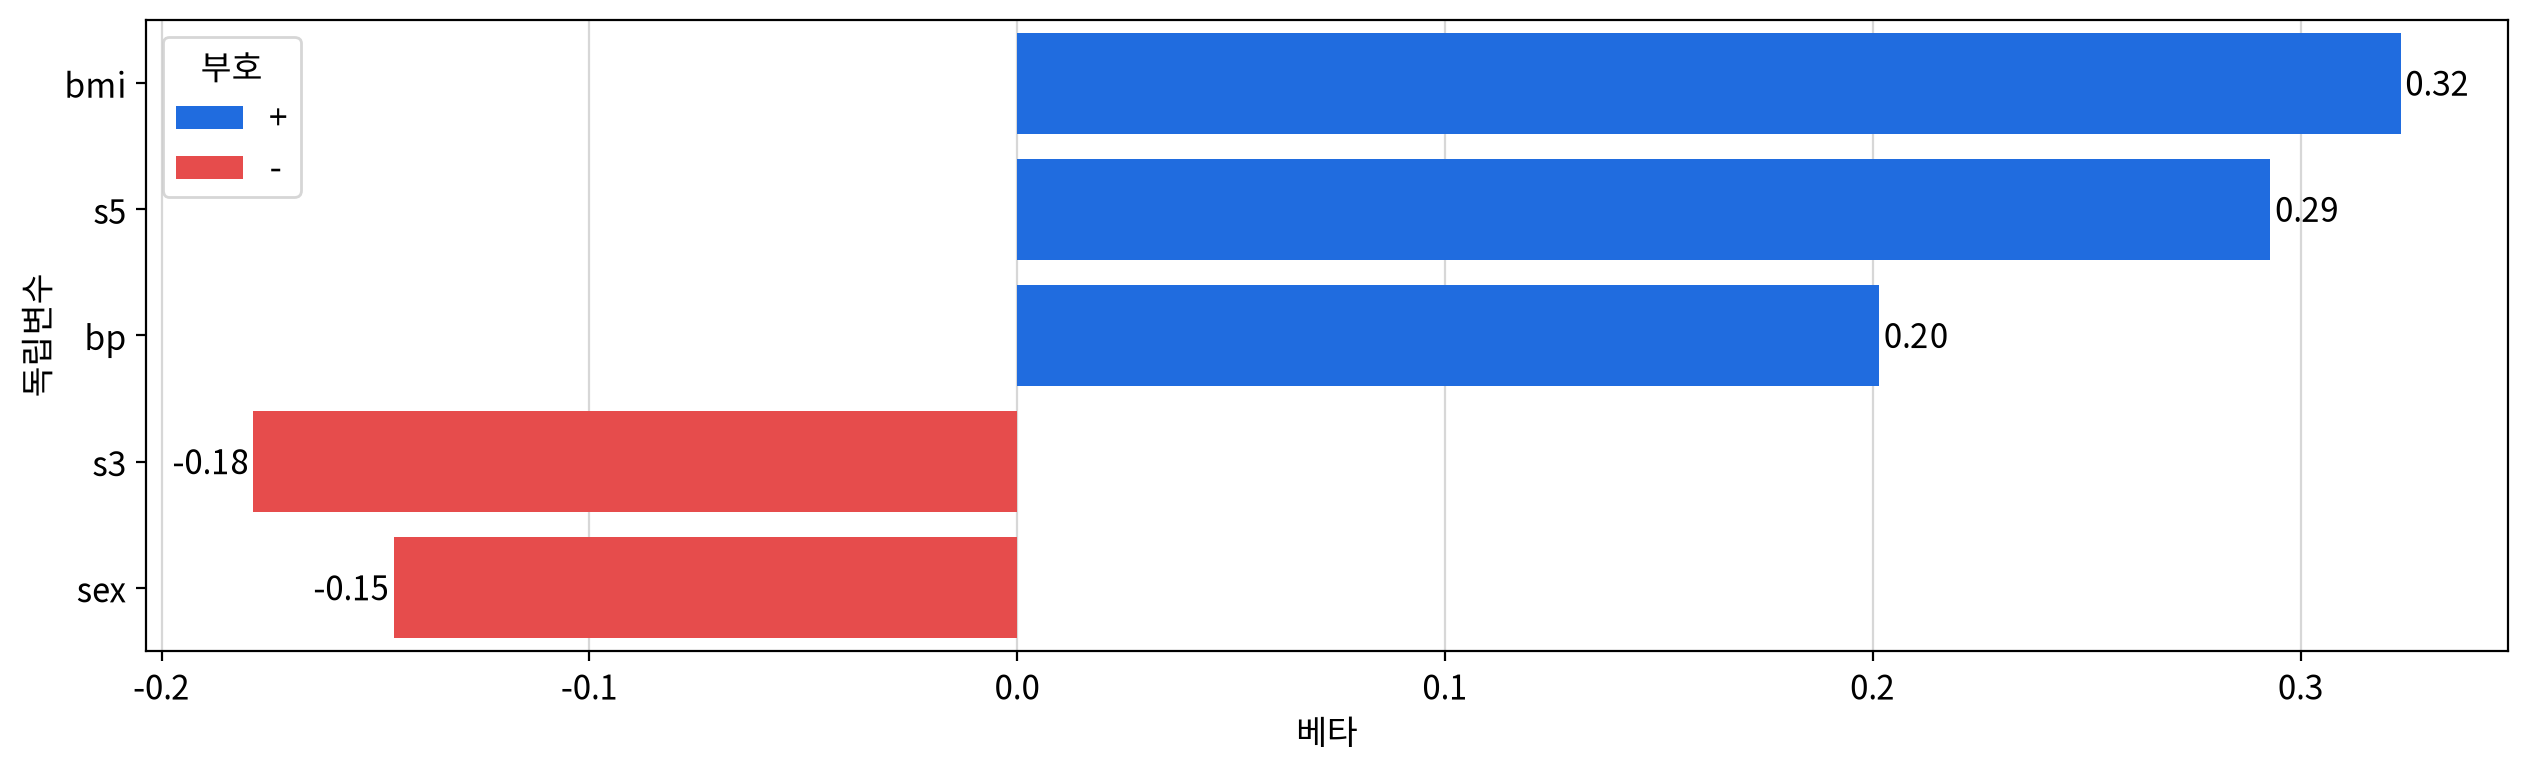

In [53]:
fig, ax = my_plot.init(height=400)
my_plot.barplot(rdf, x='베타', y='독립변수', hue='부호', 
                palette={'+':'#0066ff', '-':'#ff3333'}, ax=ax)

for i in rdf.index :
    beta = rdf.loc[i, '베타']
    sign = rdf.loc[i, '부호']
    ax.text(x=beta + 0.001*np.sign(beta), y=i, s=f"{beta:.2f}", 
            va='center', ha='left' if beta > 0 else 'right',
            color='black')

my_plot.show()

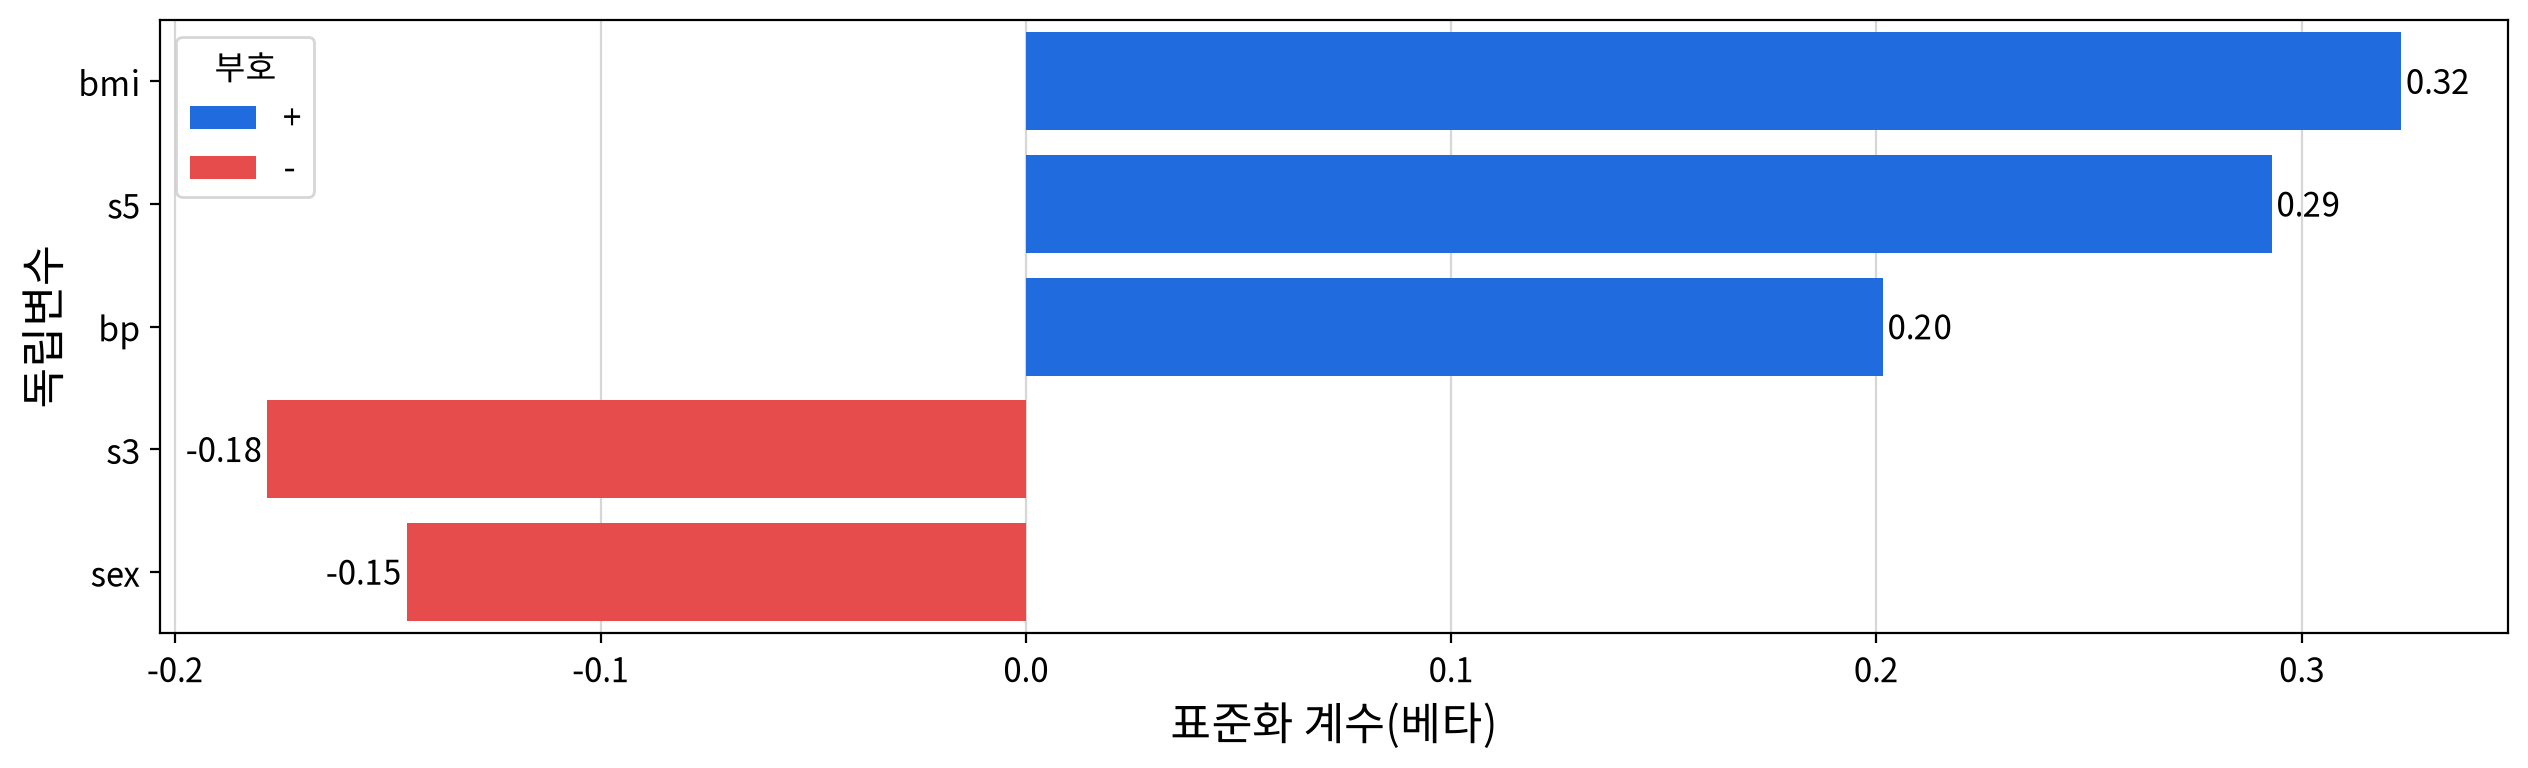

In [54]:
my_ols.plot_beta(fit6, df6)

## #01 연습문제 

In [55]:
import numpy as np
from jussam import load_data
from helpers import *

In [56]:
origin = load_data('enb')
origin.head()

📚 이 데이터 세트는 토목/구조 엔지니어인 Angeliki Xifara(angxifara@gmail.com)가 생성했으며, 영국 옥스퍼드 대학교 산업 및 응용 수학 센터의 Athanasios Tsanas(tsanasthanasis@gmail.com)가 처리했습니다.

본 연구에서는 Ecotect를 이용하여 12가지 서로 다른 건물 형태를 시뮬레이션하고 에너지 분석을 수행했습니다.

건물들은 여러 변수에서 차이를 보입니다.

이러한 특성들을 함수로 하여 다양한 설정을 시뮬레이션함으로써 총 768가지 건물 형태를 얻었습니다.

데이터셋은 768개의 샘플과 8개의 특징으로 구성되며, 두 개의 실수 값을 갖는 응답값을 예측하는 것을 목표로 합니다.

(출처: https://www.kaggle.com/datasets/elikplim/eergy-efficiency-dataset)

> 모든 데이터는 연속형 변수 입니다.


,건물조밀도,표면적,벽면적,지붕면적,높이,유리창면적,유리창면적분포,냉방부하
0,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330
1,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330
2,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330
3,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330
4,0.900,563.500,318.500,122.500,7.000,0.000,0,28.280


In [57]:
# 결측치 확인 
my_qtcheck.check_missing_values(origin)

,Missing Count,Missing Ratio (%)
건물조밀도,0,0.000
표면적,0,0.000
벽면적,0,0.000
지붕면적,0,0.000
높이,0,0.000
유리창면적,0,0.000
유리창면적분포,0,0.000
냉방부하,0,0.000


In [58]:
# 중복된 데이터 확인 check_duplicates
df1 = my_qtcheck.check_duplicates(origin)
df1

중복된 행의 수 : 16
중복된 행이 제거되었습니다.


,건물조밀도,표면적,벽면적,지붕면적,높이,유리창면적,유리창면적분포,냉방부하
0,0.980,514.500,294.000,110.250,7.000,0.000,0,21.330
4,0.900,563.500,318.500,122.500,7.000,0.000,0,28.280
5,0.900,563.500,318.500,122.500,7.000,0.000,0,25.380
6,0.900,563.500,318.500,122.500,7.000,0.000,0,25.160
7,0.900,563.500,318.500,122.500,7.000,0.000,0,29.600
...,...,...,...,...,...,...,...,...
763,0.640,784.000,343.000,220.500,3.500,0.400,5,21.400
764,0.620,808.500,367.500,220.500,3.500,0.400,5,16.880
765,0.620,808.500,367.500,220.500,3.500,0.400,5,17.110
766,0.620,808.500,367.500,220.500,3.500,0.400,5,16.610


In [59]:
# 기술통계 + 이상치 / 왜도 / 로그변환 판단 
my_qtcheck.numerical_summary(df1).T

,건물조밀도,표면적,벽면적,지붕면적,높이,유리창면적,유리창면적분포,냉방부하
count,752.000,752.000,752.000,752.000,752.000,752.000,752.000,752.000
mean,0.765,671.111,318.337,176.387,5.264,0.235,2.846,24.705
std,0.105,87.291,43.550,45.031,1.751,0.133,1.536,9.553
min,0.620,514.500,245.000,110.250,3.500,0.000,0.000,10.900
25%,0.690,606.375,294.000,147.000,3.500,0.100,2.000,15.620
50%,0.760,661.500,318.500,147.000,7.000,0.250,3.000,22.725
75%,0.830,735.000,343.000,220.500,7.000,0.400,4.000,33.233
max,0.980,808.500,416.500,220.500,7.000,0.400,5.000,48.030
rel_diff,0.006,0.015,0.001,0.200,0.248,0.061,0.051,0.087
rdiff_flag,similar,similar,similar,diff,diff,similar,similar,similar


In [60]:
# 로그변환 대상이 되는 변수 : 벽면적 

In [61]:
# 로그변환 
df2 = df1.copy()
df2['벽면적'] = np.log1p(df2['벽면적'])
df2.head()

,건물조밀도,표면적,벽면적,지붕면적,높이,유리창면적,유리창면적분포,냉방부하
0,0.980,514.500,5.687,110.250,7.000,0.000,0,21.330
4,0.900,563.500,5.767,122.500,7.000,0.000,0,28.280
5,0.900,563.500,5.767,122.500,7.000,0.000,0,25.380
6,0.900,563.500,5.767,122.500,7.000,0.000,0,25.160
7,0.900,563.500,5.767,122.500,7.000,0.000,0,29.600


### 다중 공선성 제거 

In [62]:
xnames = ['건물조밀도', '표면적', '벽면적', '지붕면적', '높이', '유리창면적', '유리창면적분포']

# 변수 제거 전의 VIF 
display(my_stats.compute_vif(df2[xnames]))

# VIF가 가장 큰 변수부터 하나씩 반복 제거 
df3 = my_prep.reduce_vif(df2, columns=xnames) 
df3.head()

,VIF
표면적,1871.738
지붕면적,833.052
벽면적,255.767
건물조밀도,203.748
높이,57.007
유리창면적,1.045
유리창면적분포,1.045


[1단계] 표면적 제거 (VIF = 1871.7)
[2단계] 지붕면적 제거 (VIF = 116.9)

완료! 남은변수 : ['건물조밀도', '높이', '벽면적', '유리창면적', '유리창면적분포']
최대 VIF = 9.71


,건물조밀도,벽면적,높이,유리창면적,유리창면적분포,냉방부하
0,0.980,5.687,7.000,0.000,0,21.330
4,0.900,5.767,7.000,0.000,0,28.280
5,0.900,5.767,7.000,0.000,0,25.380
6,0.900,5.767,7.000,0.000,0,25.160
7,0.900,5.767,7.000,0.000,0,29.600


### 1차 회귀분석 및 가정 확인 

In [63]:
fit1 = my_ols.auto_ols(df3, y='냉방부하', log_x=['벽면적'], test=True)  

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,냉방부하,높이,5.666,0.211,0.281,1.039,26.848,20.179,0.000,0.000,0.103,9.707
1,냉방부하,건물조밀도,-18.881,3.418,3.927,-0.207,-5.525,-4.808,0.000,0.000,0.110,9.112
2,냉방부하,유리창면적,14.494,0.914,0.925,0.201,15.849,15.671,0.000,0.000,0.957,1.045
3,냉방부하,벽면적,6.571,1.572,1.578,0.092,4.181,4.163,0.000,0.000,0.316,3.166
4,냉방부하,유리창면적분포,0.020,0.079,0.080,0.003,0.255,0.250,0.799,0.803,0.957,1.045


**Note. n = 752. F(5, 746) = 1148.22, p < 0.001, R^2 = 0.885, Adj.R^2 = 0.884, Durbin-Watson = 1.052**

냉방부하를 종속변수로, 건물조밀도, log(벽면적), 높이, 유리창면적, 유리창면적분포(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(5, 746) = 1148.22, p < 0.001, R^2 = 0.885.

즉, 건물조밀도, log(벽면적), 높이, 유리창면적, 유리창면적분포는 냉방부하의 약 88.5%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 3.25 , 구간 규칙 판정: 정규성 위배


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,181.827,0.000,47.579,0.000,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.052,False,독립성 위반 (양(+)의 자기상관)


### 2차 회귀분석 (유의하지 않은 변수 제거)

In [64]:
df4 =df3.drop(columns=['유리창면적분포'])
fit2 = my_ols.auto_ols(df4, y='냉방부하', log_x=['벽면적'], test=True)

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,냉방부하,높이,5.665,0.211,0.280,1.038,26.865,20.205,0.000,0.000,0.103,9.704
1,냉방부하,건물조밀도,-18.864,3.415,3.920,-0.207,-5.524,-4.812,0.000,0.000,0.110,9.109
2,냉방부하,유리창면적,14.542,0.894,0.910,0.202,16.260,15.980,0.000,0.000,0.999,1.001
3,냉방부하,벽면적,6.576,1.571,1.576,0.092,4.187,4.173,0.000,0.000,0.316,3.166


**Note. n = 752. F(4, 747) = 1437.06, p < 0.001, R^2 = 0.885, Adj.R^2 = 0.884, Durbin-Watson = 1.052**

냉방부하를 종속변수로, 건물조밀도, log(벽면적), 높이, 유리창면적(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(4, 747) = 1437.06, p < 0.001, R^2 = 0.885.

즉, 건물조밀도, log(벽면적), 높이, 유리창면적는 냉방부하의 약 88.5%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 3.25 , 구간 규칙 판정: 정규성 위배


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,181.737,0.000,59.515,0.000,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.052,False,독립성 위반 (양(+)의 자기상관)


In [65]:
fit1 = my_ols.auto_ols(df3, y='냉방부하', log_x=['벽면적'], test=True)  

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,냉방부하,높이,5.666,0.211,0.281,1.039,26.848,20.179,0.000,0.000,0.103,9.707
1,냉방부하,건물조밀도,-18.881,3.418,3.927,-0.207,-5.525,-4.808,0.000,0.000,0.110,9.112
2,냉방부하,유리창면적,14.494,0.914,0.925,0.201,15.849,15.671,0.000,0.000,0.957,1.045
3,냉방부하,벽면적,6.571,1.572,1.578,0.092,4.181,4.163,0.000,0.000,0.316,3.166
4,냉방부하,유리창면적분포,0.020,0.079,0.080,0.003,0.255,0.250,0.799,0.803,0.957,1.045


**Note. n = 752. F(5, 746) = 1148.22, p < 0.001, R^2 = 0.885, Adj.R^2 = 0.884, Durbin-Watson = 1.052**

냉방부하를 종속변수로, 건물조밀도, log(벽면적), 높이, 유리창면적, 유리창면적분포(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(5, 746) = 1148.22, p < 0.001, R^2 = 0.885.

즉, 건물조밀도, log(벽면적), 높이, 유리창면적, 유리창면적분포는 냉방부하의 약 88.5%를 설명하는 것으로 나타났다.

---

#### -> 회귀모형 가정 검정

...

루트MSE = 3.25 , 구간 규칙 판정: 정규성 위배


##### 3) 등분산성 검정

,LM statistic,LM p-value,F statistic,F p-value,homoscedasticity,result
Breusch-Pagan,181.827,0.000,47.579,0.000,False,대립가설 채택 -> 등분산 아님


##### 4) 독립성 검정

,statistic,independence,result
Durbin-Watson,1.052,False,독립성 위반 (양(+)의 자기상관)


In [66]:
df4 = df3.drop(columns=['유리창면적분포'])
fit2 = my_ols.auto_ols(df4, y='냉방부하', log_x=['벽면적'], test=False)

#### -> 모형 적합도

,종속변수,독립변수,B,표준오차,표준오차(HC3),베타,t,t(HC3),유의확률,유의확률(HC3),공차,VIF
0,냉방부하,높이,5.665,0.211,0.280,1.038,26.865,20.205,0.000,0.000,0.103,9.704
1,냉방부하,건물조밀도,-18.864,3.415,3.920,-0.207,-5.524,-4.812,0.000,0.000,0.110,9.109
2,냉방부하,유리창면적,14.542,0.894,0.910,0.202,16.260,15.980,0.000,0.000,0.999,1.001
3,냉방부하,벽면적,6.576,1.571,1.576,0.092,4.187,4.173,0.000,0.000,0.316,3.166


**Note. n = 752. F(4, 747) = 1437.06, p < 0.001, R^2 = 0.885, Adj.R^2 = 0.884, Durbin-Watson = 1.052**

냉방부하를 종속변수로, 건물조밀도, log(벽면적), 높이, 유리창면적(을)를 독립변수로한 다중선형회귀분석 결과, 모형은 통계적으로 유의하였다..

> F(4, 747) = 1437.06, p < 0.001, R^2 = 0.885.

즉, 건물조밀도, log(벽면적), 높이, 유리창면적는 냉방부하의 약 88.5%를 설명하는 것으로 나타났다.